# Моделирование распространения сигнала в аудитории 8507

### Импорты

In [123]:
import drjit as dr
import mitsuba as mi
import xml.etree.ElementTree as ET
import json
import edit_xml as ex
import os
import sionna as sn
from config import SCENE_MATERIALS, MATERIAL_COLORS
import tensorflow as tf  # Sionna работает на TF, нужен для конвертации тензоров
import numpy as np
import matplotlib.pyplot as plt


# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

no_preview = True # Toggle to False to use the preview widget
                  # instead of rendering for scene visualization

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, ITURadioMaterial, SceneObject, PlanarRadioMap, subcarrier_frequencies

from sionna.phy.channel.utils import cir_to_ofdm_channel


### Загрузка сцены

Файл `room.xml` изначально был создан в Blender 3.6. Сцена представляет собой кабинет, с двумя пространствами, отделенными друг от друга стеклянной перегородкой. 3D модель экспортирована с помощью плагина Mitsuba c кастомными настройками(вверх Z, вперед Y) По умолчанию загрузка сцены происходит с флагом `merge_shapes=True`, который объеденияет все объекты с одинаковыми радиоматериалами.

In [124]:
scene = load_scene("room.xml", merge_shapes=False)

Обработка файла, настройка отображения цвета, доопределение свойств материалов.

In [125]:
# Материалам при визуализации будут присвоены правильные цвета
ex.update_material_colors("room.xml", MATERIAL_COLORS)

# Присвоение элементам сцены таких же имен и ID, как и у объектов 3D модели
ex.set_shape_ids_from_filename("room.xml")


# Перезагрузка сцены, объекты не объединины по радиоматериалам
scene = load_scene("room.xml", merge_shapes=False)

print("Available objects:", list(scene.objects.keys()))

# Назначение радиоматериалов и толщины объектам сцены
ex.apply_materials_from_config(scene, SCENE_MATERIALS)


Available objects: ['wall', 'floor', 'partition', 'table2', 'table1', 'table3', 'comp1', 'comp2', 'comp3', 'point_001', 'point_002', 'point_003']


Создание экземпляров камер,визуализация.

In [126]:
cam = Camera(position=[0,0,10],  look_at=[0,0,0])
cam_1 = Camera(position=[10,-5,12], look_at=[0,0,0])

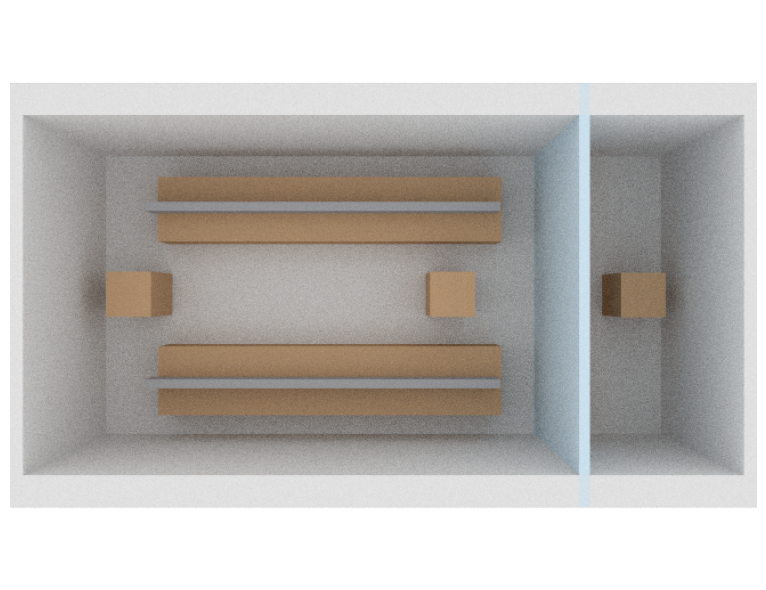

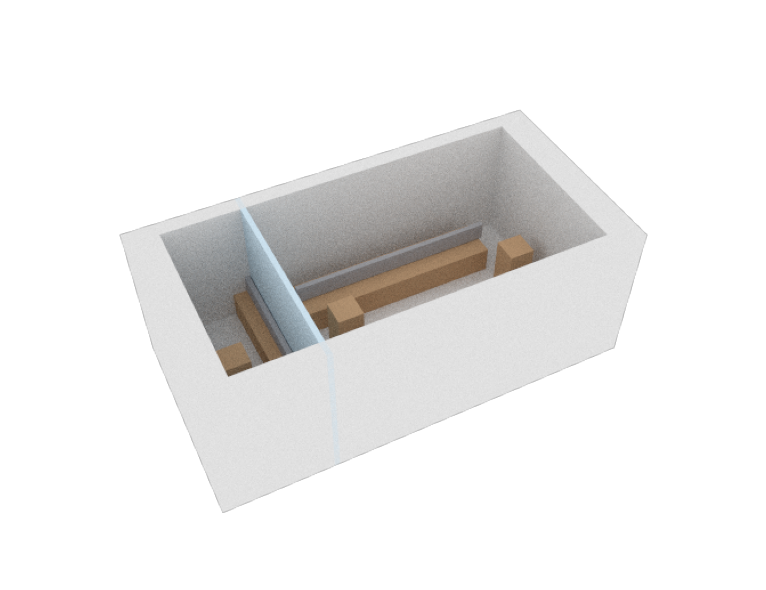

In [127]:
if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

if no_preview:
    scene.render(camera=cam_1);
else:
    scene.preview();

In [128]:

# Позиции без изменений
tx_pos = [0, 2.82, -0.486 + 0.6+1]
rx_1_pos = [0, -2.92, -0.486 + 0.6]
rx_2_pos = [0, -0.766, -0.4853 + 0.6]

# Безопасная замена существующих объектов
for name in ["tx", "rx-1", "rx-2"]:
    scene.remove(name)

scene.add(Transmitter("tx", position=tx_pos, display_radius=0.01))
#scene.add(Receiver("rx-1", position=rx_1_pos, display_radius=0.01))
scene.add(Receiver("rx-2", position=rx_2_pos, display_radius=0.01))

# Антенная конфигурация, аппроксимирующая Intel AX210
ax210_array = PlanarArray(num_rows=1,
                          num_cols=1,
                          pattern="dipole",
                          polarization="VH")

scene.tx_array = ax210_array
scene.rx_array = ax210_array

In [129]:
#p_solver = PathSolver()
#paths = p_solver(scene, max_depth=2)

p_solver = PathSolver()
result = p_solver(
    scene=scene,
    max_depth=4,
    los=True,
    specular_reflection=True,
    refraction=True,
    diffuse_reflection=False,
    synthetic_array=False,
    seed=42
)


In [ ]:
if no_preview:
    scene.render(camera=cam, paths=result);
else:
    scene.preview(paths=result)


if no_preview:
    scene.render(camera=cam_1, paths=result);
else:
    scene.preview(paths=result)

In [ ]:
# Получение импульсной характеристики канала
a, tau = result.cir(normalize_delays=True, out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a: ", a.shape)

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
print("Shape of tau: ", tau.shape)

Shape of a:  (1, 2, 1, 2, 69, 1)
Shape of tau:  (1, 2, 1, 2, 69)


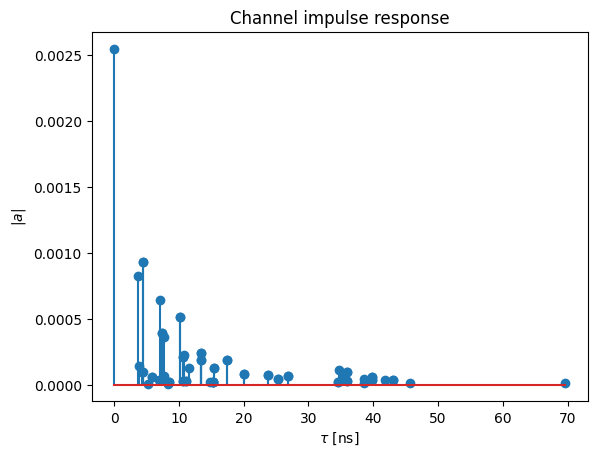

In [ ]:
# OFDM system parameters
num_subcarriers = 1024
subcarrier_spacing=30e3

# Compute frequencies of subcarriers relative to the carrier frequency
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

# Compute channel frequency response
h_freq = result.cfr(frequencies=frequencies,
                   normalize=True, # Normalize energy
                   normalize_delays=True,
                   out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, num_subcarriers]
print("Shape of h_freq: ", h_freq.shape)

# Plot absolute value
plt.figure()
plt.plot(np.abs(h_freq)[0,0,0,0,0,:]);
plt.xlabel("Subcarrier index");
plt.ylabel(r"|$h_\text{freq}$|");
plt.title("Channel frequency response");

In [ ]:

# 2. Извлечение данных (правильно, согласно документации)
# paths.a — это tuple (real, imag), объединяем в комплексный тензор
a_real = result.a[0].numpy()   # Вещественная часть
a_imag = result.a[1].numpy()   # Мнимая часть
amplitudes = a_real + 1j * a_imag  # Комплексные коэффициенты

# Задержки и маска валидных путей
delays = result.tau.numpy()           # [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
valid_mask = result.valid.numpy()     # [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]

# 3. Приведение размерностей к удобному виду
# Документация: [Rx, RxAnt, Tx, TxAnt, Paths]
# Переставляем оси в порядок: [Tx, TxAnt, Rx, RxAnt, Paths]
amplitudes = np.moveaxis(amplitudes, [0, 1, 2, 3, 4], [2, 3, 0, 1, 4])
delays = np.moveaxis(delays, [0, 1, 2, 3, 4], [2, 3, 0, 1, 4])
valid_mask = np.moveaxis(valid_mask, [0, 1, 2, 3, 4], [2, 3, 0, 1, 4])

# 4. Расчёт затухания (Path Loss) в дБ
path_loss_db = -20.0 * np.log10(np.abs(amplitudes) + 1e-10)

# 5. Статистика для пары Tx[0] → Rx[0], поляризация V-V (индексы антенн 0,0)
tx_idx, rx_idx = 0, 0
ant_tx, ant_rx = 0, 0  # Первая поляризация (Vertical)
valid = valid_mask[tx_idx, ant_tx, rx_idx, ant_rx, :]

pl_valid = path_loss_db[tx_idx, ant_tx, rx_idx, ant_rx, valid]
tau_valid = delays[tx_idx, ant_tx, rx_idx, ant_rx, valid] * 1e9  # в наносекундах

print(f"=== Статистика для Tx[{tx_idx}] → Rx[{rx_idx}], V-V поляризация ===")
print(f"Число путей: {valid.sum()}")
print(f"Задержки (нс): {tau_valid}")
print(f"Затухание (дБ): {pl_valid}")
print(f"Range затухания: {pl_valid.max() - pl_valid.min():.2f} дБ")


=== Статистика для Tx[0] → Rx[0], V-V поляризация ===
Число путей: 69
Задержки (нс): [12.417367 16.17807  20.695068 16.817055 16.817055 19.757336 19.757336
 20.111872 58.129482 47.077484 23.08932  32.500195 52.25685  47.742958
 52.185123 48.42429  23.936468 27.631107 25.858854 27.860714 25.858854
 22.518843 25.891998 22.518843 37.67401  27.631107 29.88252  36.21867
 47.03348  52.25685  36.218674 47.033478 18.226765 18.226767 20.970314
 20.970312 23.089172 19.454456 23.08917  27.860714 23.276022 25.892
 20.112043 27.631107 23.08932  27.631107 23.590248 23.590248 48.424286
 39.192818 55.43938  52.185123 29.88252  39.19282  50.93785  37.674015
 27.243568 32.500195 55.43938  51.07099  54.266953 82.02481  48.433952
 48.419876 19.33658  16.844868 16.320677 16.804363 17.578623]
Затухание (дБ): [ 51.873924  61.647232 101.29326   60.639477  60.639477  68.214
  68.214005  83.97351   97.529785  79.25855   73.45262   81.683235
  84.5408    83.8772    88.38769   80.27993   77.91606   94.38608
  72.